In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV
df = pd.read_csv("ecommerce.csv", low_memory=False)

# Convert dates (replace format if necessary)
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Numeric columns
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Cost",
    "Aging"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("₹", "", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

# Categorical columns
categorical_cols = [
    "Order ID",
    "Ship Mode",
    "Product Category",
    "Product",
    "Order Priority",
    "Customer ID",
    "Customer Name",
    "Segment",
    "City",
    "State",
    "Country",
    "Region",
    "Months"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print(df.dtypes)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21560\4263838100.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21560\4263838100.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


Order ID                  category
Order Date          datetime64[us]
Ship Date           datetime64[us]
Aging                      float64
Ship Mode                 category
Product Category          category
Product                   category
Sales                      float64
Quantity                   float64
Discount                   float64
Profit                     float64
Shipping Cost              float64
Order Priority            category
Customer ID               category
Customer Name             category
Segment                   category
City                      category
State                     category
Country                   category
Region                    category
Months                    category
dtype: object


In [26]:
print(df.shape)
print(df.info())
print(df.describe())

df.isnull().sum()

(51290, 21)
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          51290 non-null  category      
 1   Order Date        51289 non-null  datetime64[us]
 2   Ship Date         51290 non-null  datetime64[us]
 3   Aging             51289 non-null  float64       
 4   Ship Mode         51290 non-null  category      
 5   Product Category  51290 non-null  category      
 6   Product           51290 non-null  category      
 7   Sales             51289 non-null  float64       
 8   Quantity          51288 non-null  float64       
 9   Discount          51289 non-null  float64       
 10  Profit            51290 non-null  float64       
 11  Shipping Cost     51289 non-null  float64       
 12  Order Priority    51288 non-null  category      
 13  Customer ID       51289 non-null  category      
 14  Customer Name     512

Order ID            0
Order Date          1
Ship Date           0
Aging               1
Ship Mode           0
Product Category    0
Product             0
Sales               1
Quantity            2
Discount            1
Profit              0
Shipping Cost       1
Order Priority      2
Customer ID         1
Customer Name       0
Segment             1
City                0
State               0
Country             0
Region              1
Months              0
dtype: int64

In [27]:
#1. Overall Sales Performance
print("Total Sales :", df["Sales"].sum())
print("Total Profit :", df["Profit"].sum())
print("Total Quantity :", df["Quantity"].sum())
print("Total Shipping Cost :", df["Shipping Cost"].sum())

Total Sales : 8023170.0
Total Profit : 3730073.3000000003
Total Quantity : 153729.0
Total Shipping Cost : 373021.4


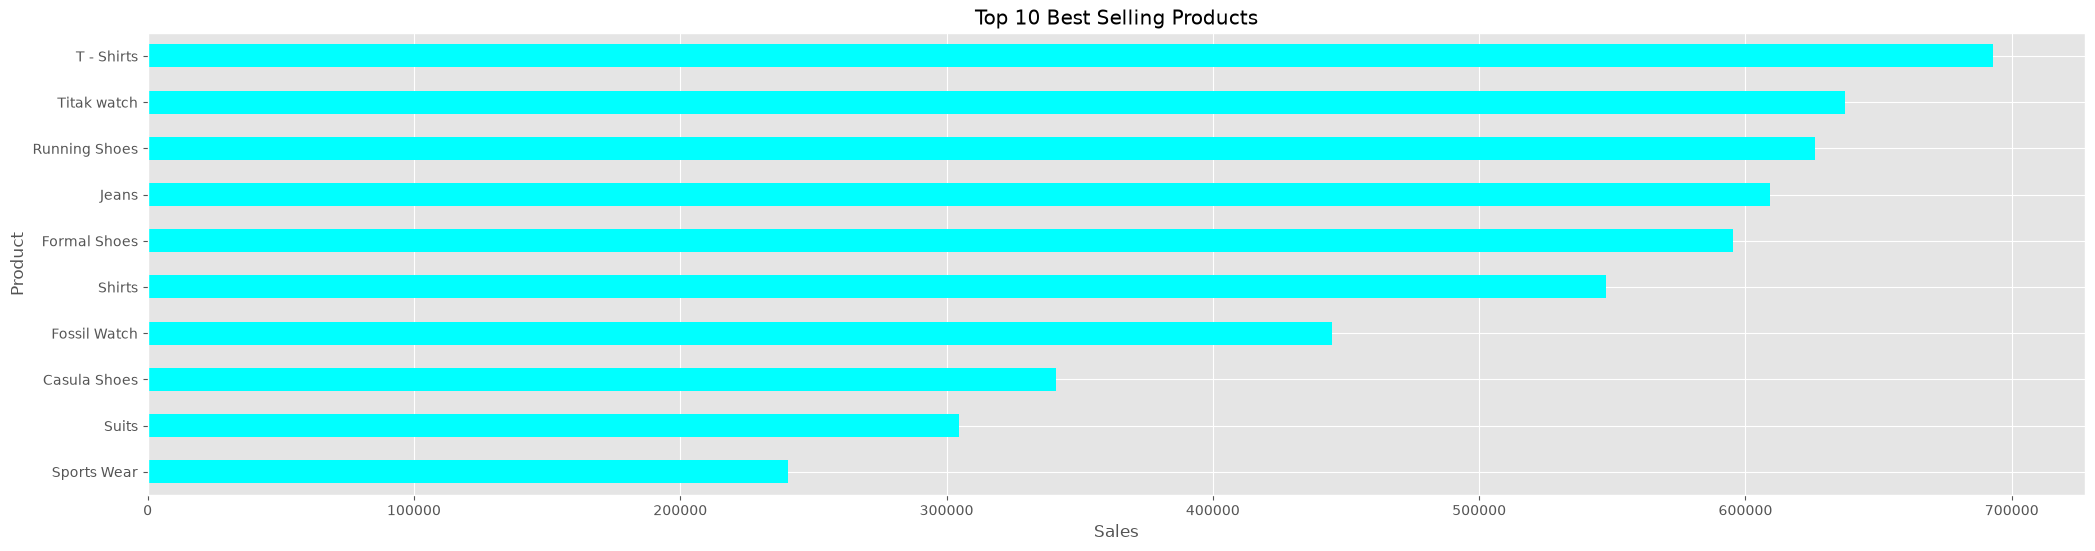

In [30]:
#2. Top 10 Best Selling Products
top_products = (df.groupby("Product")["Sales"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
plt.figure(figsize=(25,6))
top_products.sort_values().plot(kind="barh",color="cyan")
plt.title("Top 10 Best Selling Products")
plt.xlabel("Sales")
plt.show()

                        Sales     Profit  Quantity
Product Category                                  
Auto & Accessories  1096928.0   484313.2   22392.0
Electronic           394738.0   174190.6    8211.0
Fashion             5212097.0  2483955.2   92071.0
Home & Furniture    1319407.0   587614.3   31055.0


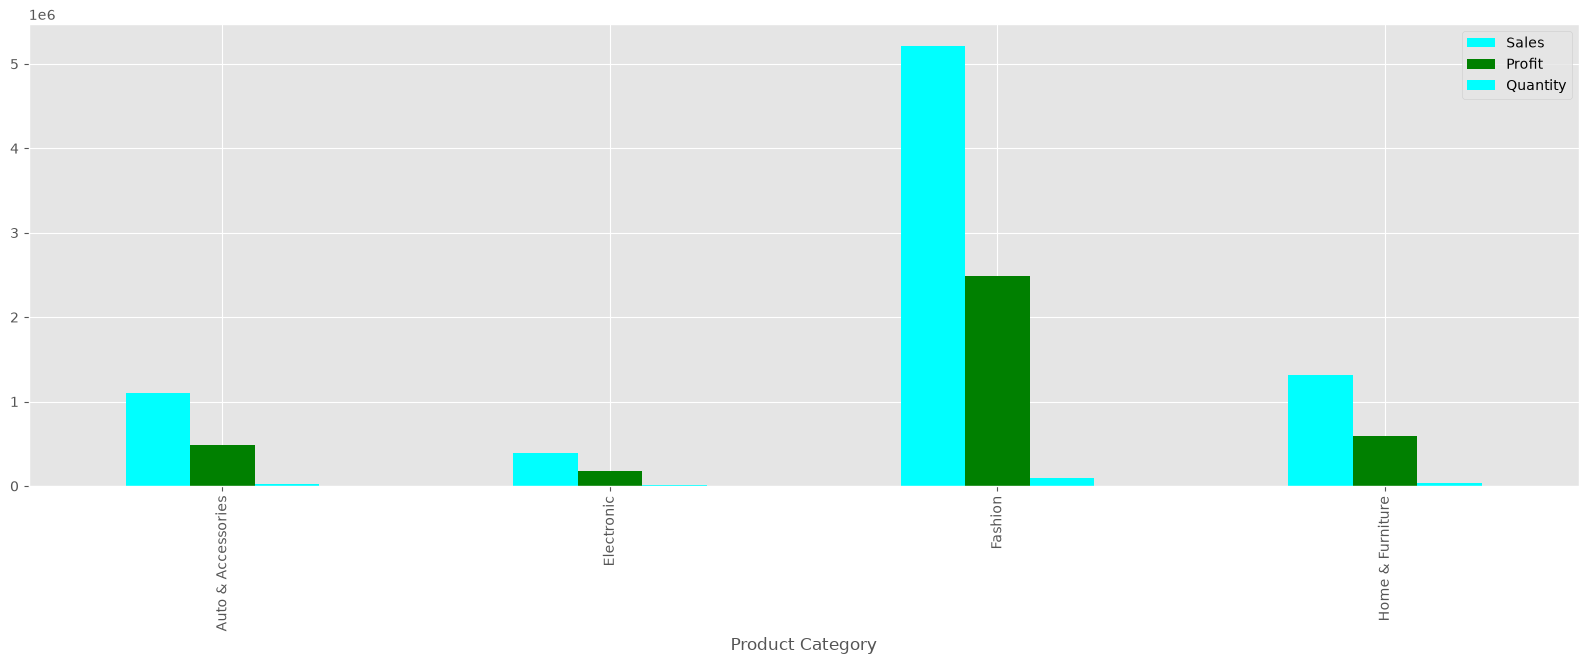

In [41]:
#3. Product Category Analysis
category = df.groupby("Product Category").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Quantity=("Quantity","sum")
)
print(category)
category.plot(kind="bar",figsize=(20,6),color=("cyan","green"))
plt.show()

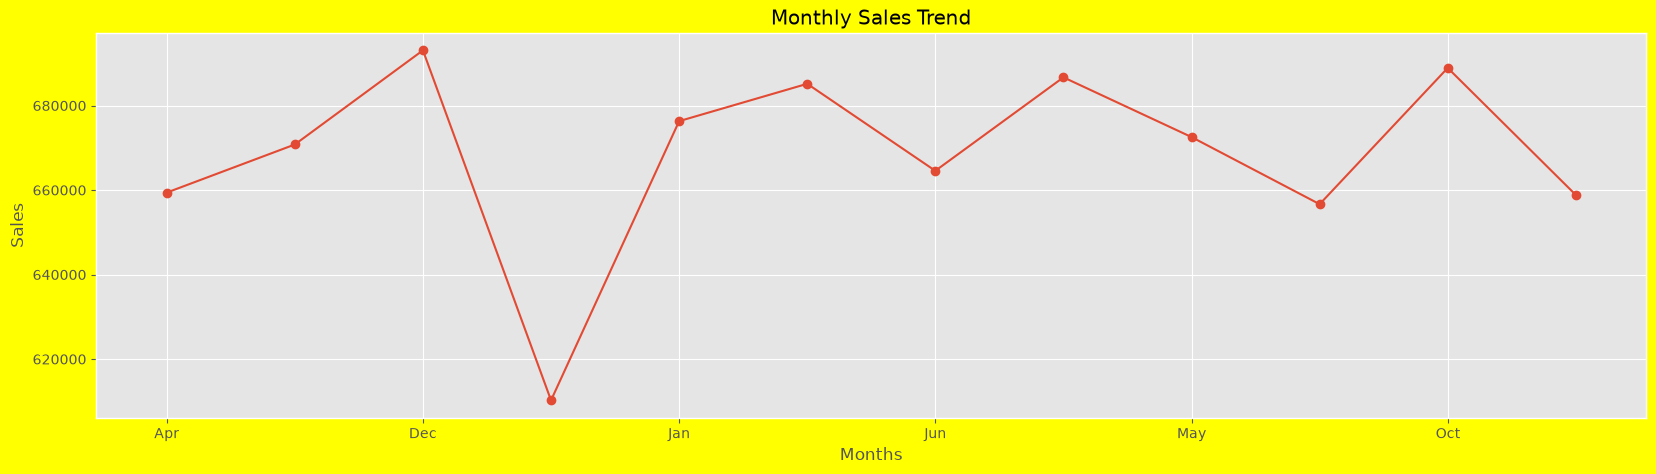

In [47]:
#4. Monthly Sales Trend
monthly = df.groupby("Months")["Sales"].sum()
plt.figure(figsize=(20,5),facecolor="yellow")
monthly.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

                    Sales    Profit
Region                             
4orth               117.0      33.5
Africa           713074.0  332220.0
Canada            60003.0   27783.1
Caribbean        260495.0  120608.1
Central         1735900.0  804210.0
Central Asia     321005.0  149529.7
EMEA             788072.0  368570.7
East             446468.0  206694.5
North            750365.0  349269.5
North Asia       369816.0  170918.3
Oceania          544827.0  253691.7
So3th               211.0      99.4
South           1034533.0  479016.5
Southeast Asia   500712.0  235598.1
West             497432.0  231775.8


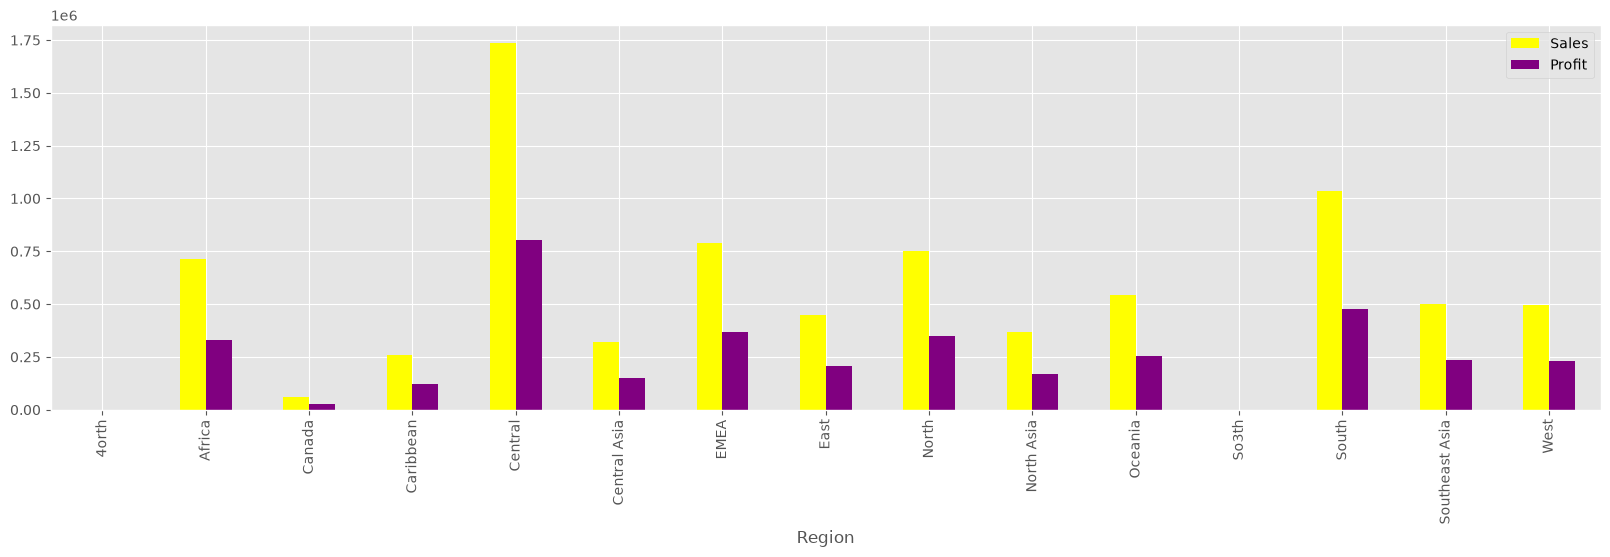

In [46]:
#5. Regional Sales Analysis
region = df.groupby("Region")[["Sales","Profit"]].sum()
print(region)
region.plot(kind="bar",figsize=(20,5),color=("yellow","purple"))
plt.show()

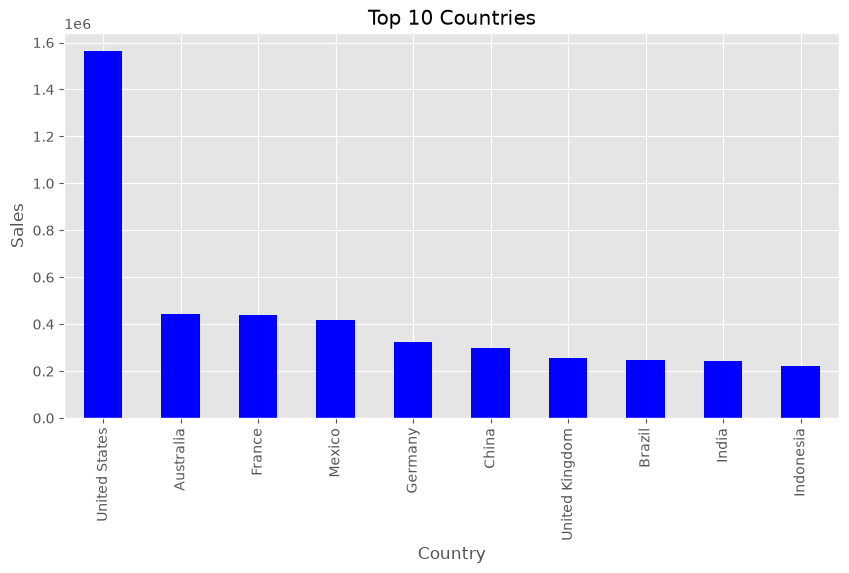

In [50]:
#6. Country-wise Revenue Analysis
country = (df.groupby("Country")["Sales"]
             .sum()
             .sort_values(ascending=False)
             .head(10))
country.plot(kind="bar",figsize=(10,5),color="blue")
plt.title("Top 10 Countries")
plt.ylabel("Sales")
plt.show()

In [51]:
#7. State-wise Profit Analysis
state_profit = df.groupby("State")["Profit"].sum().sort_values()
print("Bottom 15 States")
print(state_profit.head(15))
print()
print("Top 15 States")
print(state_profit.tail(15))

Bottom 15 States
State
Isparta               0.8
Kabarole              6.8
Inhambane             7.2
Caras-Severin        12.4
Savanes              15.6
Bitola               17.0
Guelmim-Es Semara    17.5
Ibb                  18.0
Shumen               19.5
Kara                 19.5
Okayama              20.3
South Chungcheong    20.3
Grand Gedeh          21.2
Novosibirsk          21.3
Mashonaland West     21.3
Name: Profit, dtype: float64

Top 15 States
State
Victoria                   34400.5
Illinois                   34632.3
Distrito Federal           34988.7
Washington                 36666.3
Pennsylvania               43675.1
National Capital           43966.6
San Salvador               45997.0
North Rhine-Westphalia     50167.2
Queensland                 52913.3
New South Wales            56253.6
Ile-de-France              70627.9
Texas                      72492.1
New York                   80855.4
England                   109275.5
California                142905.2
Name: Profit

In [52]:
#8. Customer Segment Analysis
segment = df.groupby("Segment").agg(
Sales=("Sales","sum"),
Profit=("Profit","sum"),
Average_Order_Value=("Sales","mean")
)
print(segment)

                 Sales     Profit  Average_Order_Value
Segment                                               
Consumer     4135010.0  1915800.9           155.938077
Corporate    2421560.0  1128812.0           156.948603
Home Office  1466528.0   685446.0           156.982231


In [53]:
#9. Ship Mode Performance
ship = df.groupby("Ship Mode").agg(
Average_Shipping_Cost=("Shipping Cost","mean"),
Average_Aging=("Aging","mean"),
Total_Sales=("Sales","sum")
)
print(ship)

                Average_Shipping_Cost  Average_Aging  Total_Sales
Ship Mode                                                        
45788                        0.600000       9.000000        114.0
First Class                  6.454165       5.541850    1096814.0
Same Day                     6.455313       1.000000     394738.0
Second Class                 5.703114       5.454845    1319407.0
Standard Class               8.070382       5.491503    5212097.0


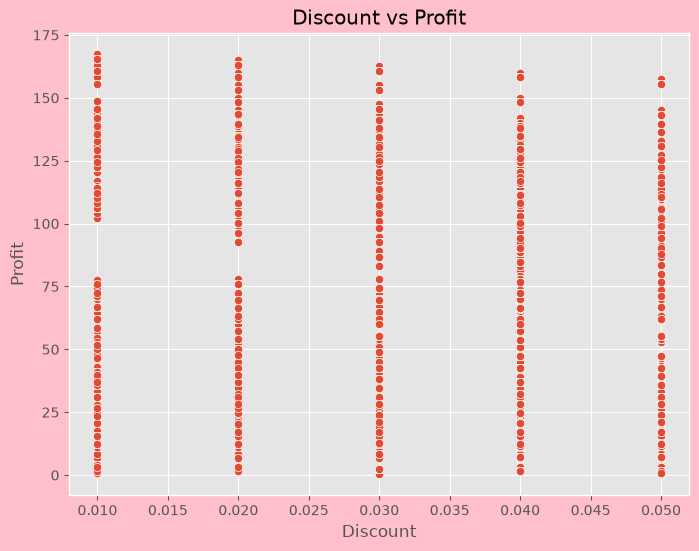

          Discount    Profit
Discount  1.000000 -0.119078
Profit   -0.119078  1.000000


In [60]:
#10. Discount vs Profit Analysis
plt.figure(figsize=(8,6),facecolor="pink")
sns.scatterplot(data=df,
                x="Discount",
                y="Profit")
plt.title("Discount vs Profit")
plt.show()
print(df[["Discount","Profit"]].corr())

                    Sales     Profit
Order Priority                      
Critical         544404.0   239239.6
High            2348534.0  1081889.7
Low              411004.0   195904.5
Medium          4718747.0  2212750.8


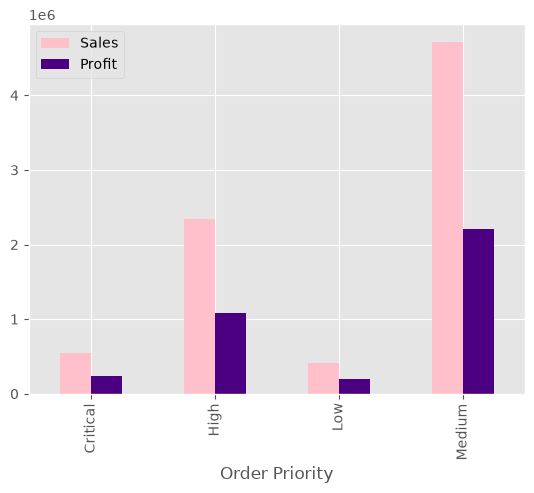

In [62]:
#11. Order Priority Analysis
priority = df.groupby("Order Priority")[["Sales","Profit"]].sum()
print(priority)
priority.plot(kind="bar",color=("pink","indigo"))
plt.show()

In [63]:
#12. Top Customers
customer = df.groupby("Customer Name").agg(
Sales=("Sales","sum"),
Profit=("Profit","sum")
).sort_values(by="Sales",ascending=False)
print(customer.head(20))

                     Sales  Profit
Customer Name                     
Mcclain O'Donnell  17015.0  7592.2
Weber Halladay     16632.0  7877.1
Leon Sissman       16321.0  7960.3
Booth Pistole      16291.0  7707.6
Ellis Carmichael   16174.0  7891.9
Bates Gockenbach   15968.0  7545.8
Bell Bickford      15932.0  7748.0
Spears Thornton    15922.0  7443.6
Graves Garza       15833.0  7830.7
Flores Brooks      15807.0  7250.5
Robertson Coakley  15635.0  7529.7
Kelly Braden       15593.0  7418.9
Skinner Nguyen     15332.0  7269.1
Ryan Dominguez     15160.0  7132.2
Mcdowell Roelle    15048.0  6838.7
Preston Savely     15010.0  7165.0
Barnett Garverick  14946.0  7321.4
Wiley Pölking      14883.0  7234.3
Oneill Williams    14719.0  6853.8
Meyers Pelletier   14637.0  6772.8


In [64]:
#13. Loss Making Orders
loss = df[df["Profit"]<0]
print(loss)
print(loss.groupby("Product Category")["Profit"].count())
print(loss.groupby("Discount")["Profit"].count())
print(loss.groupby("Ship Mode")["Profit"].count())

Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Aging, Ship Mode, Product Category, Product, Sales, Quantity, Discount, Profit, Shipping Cost, Order Priority, Customer ID, Customer Name, Segment, City, State, Country, Region, Months]
Index: []

[0 rows x 21 columns]
Series([], Name: Profit, dtype: int64)
Series([], Name: Profit, dtype: int64)
Series([], Name: Profit, dtype: int64)


Ship Mode
45788             9.000000
First Class       5.541850
Same Day          1.000000
Second Class      5.454845
Standard Class    5.491503
Name: Aging, dtype: float64


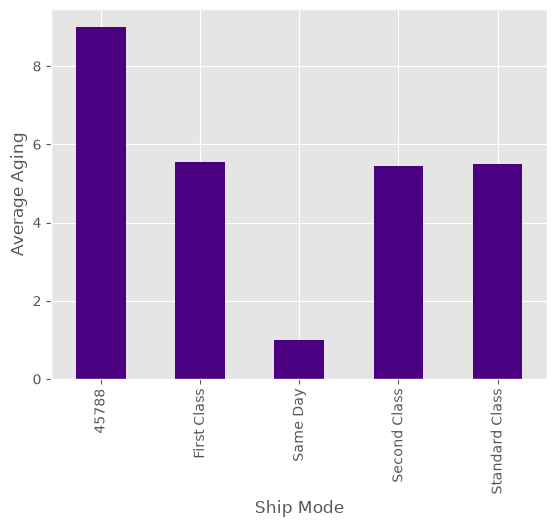

In [67]:
#14. Aging Analysis
aging = df.groupby("Ship Mode")["Aging"].mean()
print(aging)
aging.plot(kind="bar",color="indigo")
plt.ylabel("Average Aging")
plt.show()

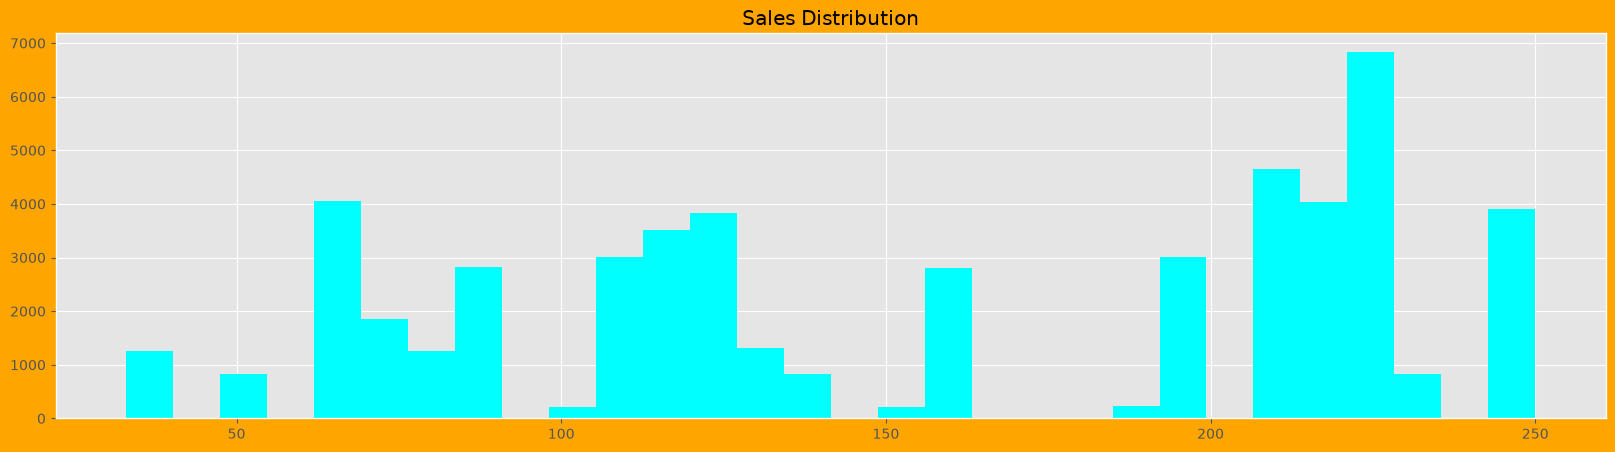

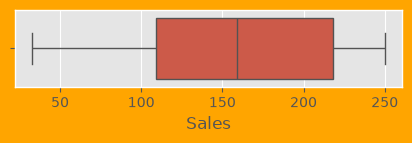

In [78]:
#15. Sales Distribution
plt.figure(figsize=(20,5),facecolor="orange")
plt.hist(df["Sales"],bins=30,color="cyan")
plt.title("Sales Distribution")
plt.show()
plt.figure(figsize=(5,1),facecolor="orange")
sns.boxplot(x=df["Sales"])
plt.show()

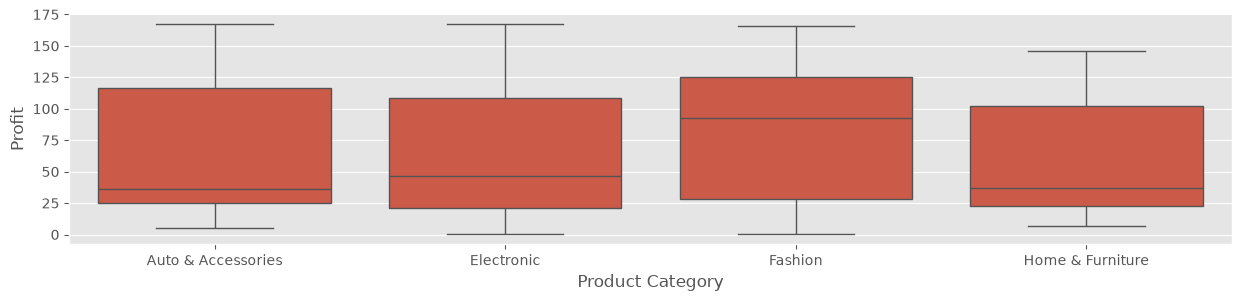

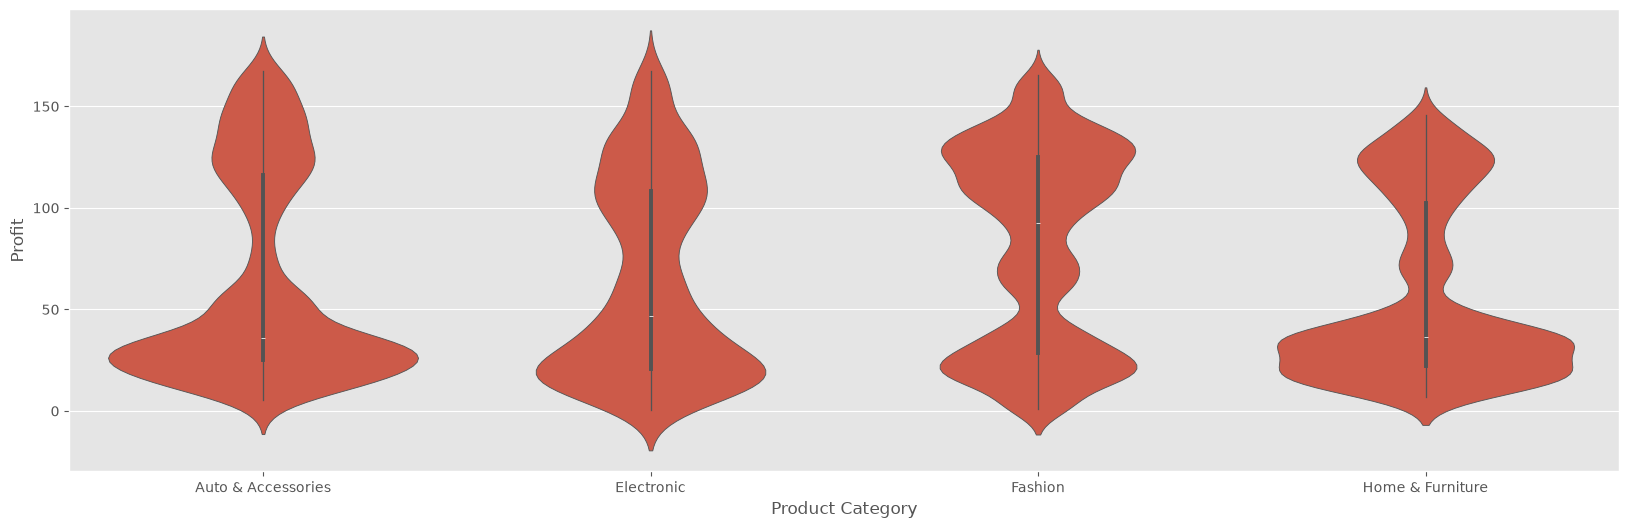

In [82]:
#16. Profit Distribution by Category
plt.figure(figsize=(15,3),)
sns.boxplot(data=df,
            x="Product Category",
            y="Profit")
plt.show()
plt.figure(figsize=(20,6))
sns.violinplot(data=df,
               x="Product Category",
               y="Profit")
plt.show()

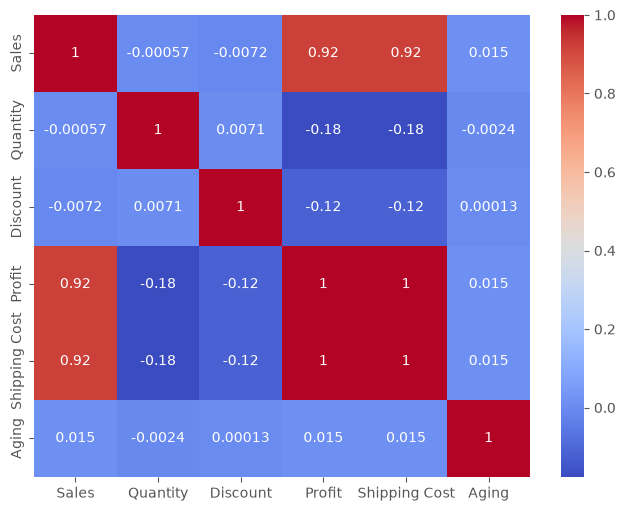

In [83]:
#17. Correlation Analysis
corr = df[["Sales",
           "Quantity",
           "Discount",
           "Profit",
           "Shipping Cost",
           "Aging"]].corr()
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()

            Order ID Order Date  Ship Date  Aging       Ship Mode  \
1          AU-2015-2 2015-06-30 2015-07-02    2.0     First Class   
4          AU-2015-5 2015-07-09 2015-07-18    9.0     First Class   
8          AU-2015-9 2015-02-09 2015-02-16    7.0     First Class   
10        AU-2015-11 2015-11-16 2015-11-26   10.0     First Class   
13        AU-2015-14 2015-07-22 2015-07-27    5.0     First Class   
...              ...        ...        ...    ...             ...   
51249  FA-2015-30735 2015-06-03 2015-06-10    7.0  Standard Class   
51253  FA-2015-30739 2015-03-25 2015-04-01    7.0  Standard Class   
51254  FA-2015-30740 2015-09-16 2015-09-18    2.0  Standard Class   
51256  FA-2015-30742 2015-02-21 2015-02-28    7.0  Standard Class   
51257  FA-2015-30743 2015-02-24 2015-03-03    7.0  Standard Class   

         Product Category                 Product  Sales  Quantity  Discount  \
1      Auto & Accessories            Car Speakers  211.0       3.0      0.03   
4      Auto

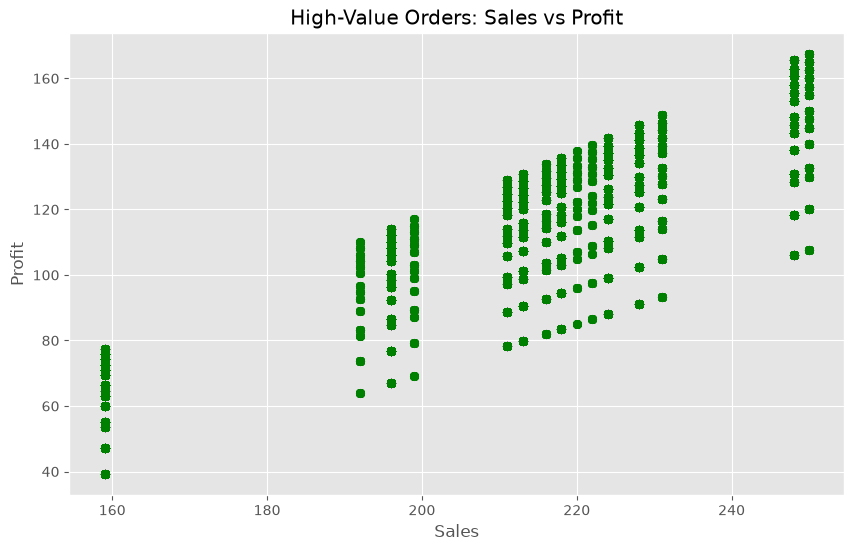

In [87]:
#18. High Value Orders
average_sales = df["Sales"].mean()
high_orders = df[df["Sales"]>average_sales]
print(high_orders)
print(high_orders.describe())
plt.figure(figsize=(10,6))

plt.scatter(high_orders["Sales"],
            high_orders["Profit"],
            color="green")

plt.title("High-Value Orders: Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

                    Orders    Sales  Average_Order_Value
Customer Name                                           
Mcclain O'Donnell      108  17015.0           157.546296
Spears Thornton        106  15922.0           150.207547
Bates Gockenbach       102  15968.0           156.549020
Flores Brooks          102  15807.0           154.970588
Booth Pistole          102  16291.0           159.715686
...                    ...      ...                  ...
Fleming Foster          35   5782.0           165.200000
Wheeler Donatelli       34   5575.0           163.970588
Kelley Devincentis      31   4411.0           142.290323
Beasley Pawlan          31   4249.0           137.064516
Oconnor Nelson          29   5001.0           172.448276

[795 rows x 3 columns]

Repeat Customers
                        Orders    Sales  Average_Order_Value
Customer Name                                               
Abbott Mackendrick          63  10106.0           160.412698
Acosta Morse                62  10

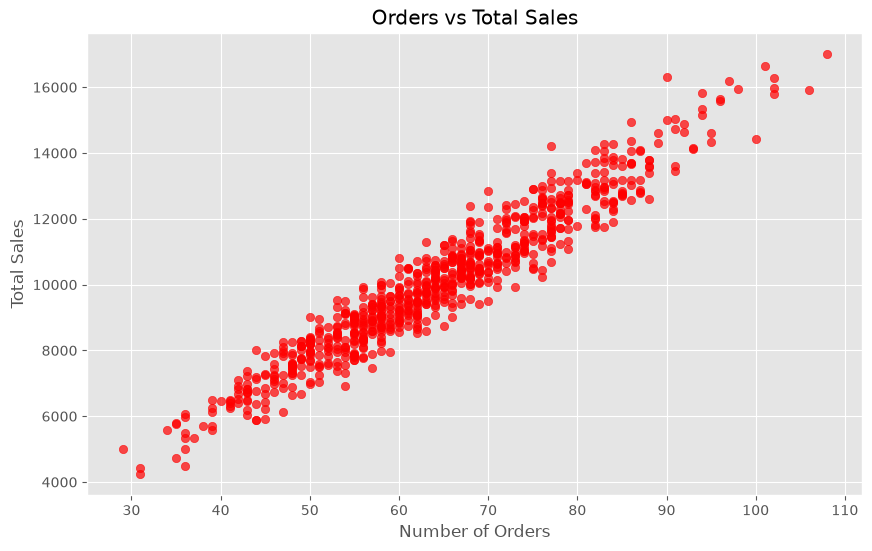

In [88]:
#19. Customer Purchase Frequency
purchase = df.groupby("Customer Name").agg(
Orders=("Order ID","count"),
Sales=("Sales","sum"),
Average_Order_Value=("Sales","mean")
)
print(purchase.sort_values(by="Orders",ascending=False))
repeat = purchase[purchase["Orders"]>1]
print()
print("Repeat Customers")
print(repeat)
plt.figure(figsize=(10,6))

plt.scatter(purchase["Orders"],
            purchase["Sales"],
            color="red",
            alpha=0.7)

plt.title("Orders vs Total Sales")
plt.xlabel("Number of Orders")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

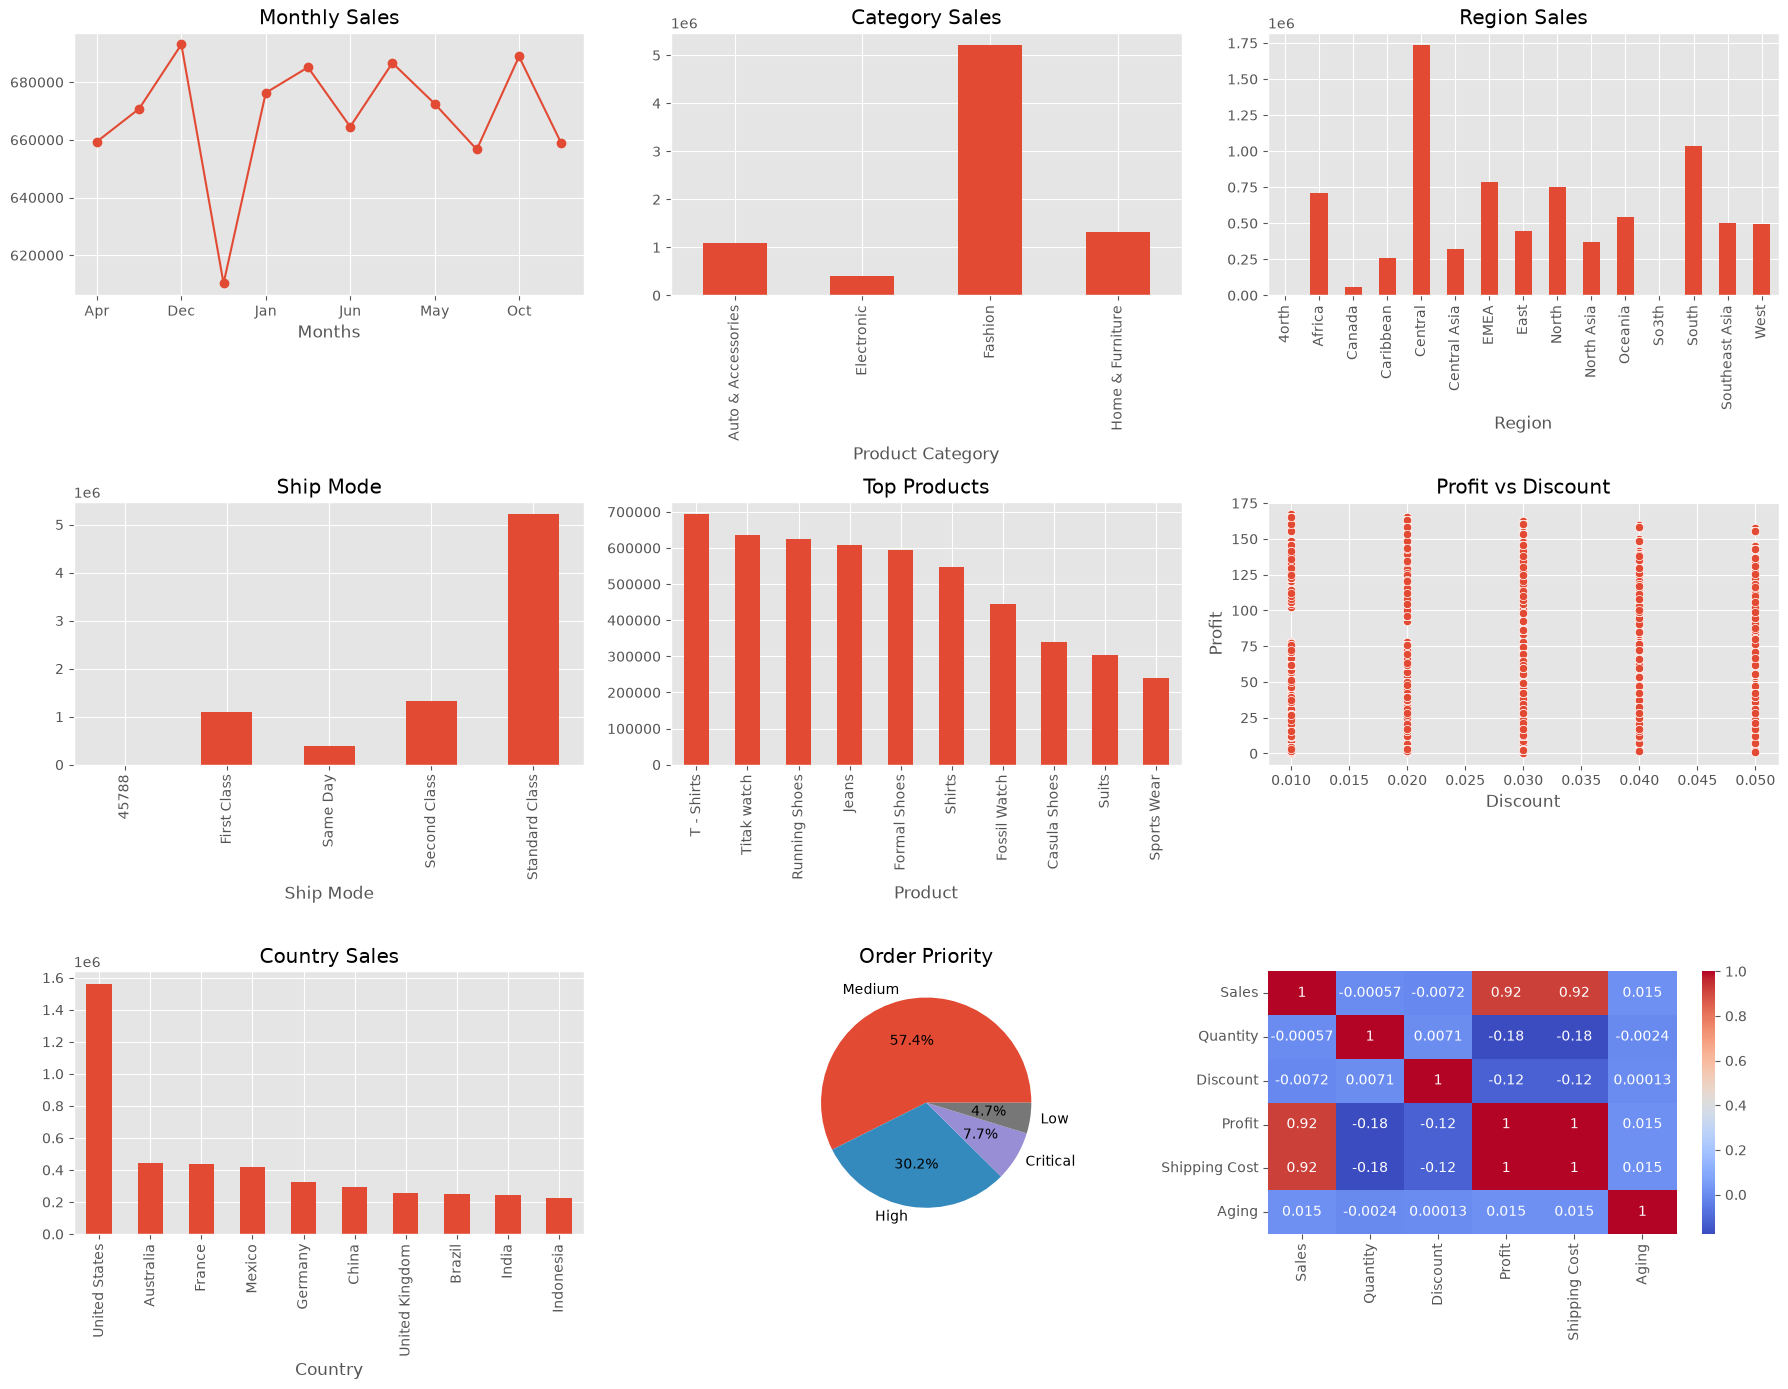

Total Sales : 8023170.0
Total Profit : 3730073.3000000003
Total Orders : 51290
Total Customers : 51289


In [86]:
#20. Executive Sales Dashboard
fig=plt.figure(figsize=(18,14))
# 1
plt.subplot(3,3,1)
df.groupby("Months")["Sales"].sum().plot(marker="o")
plt.title("Monthly Sales")
# 2
plt.subplot(3,3,2)
df.groupby("Product Category")["Sales"].sum().plot(kind="bar")
plt.title("Category Sales")
# 3
plt.subplot(3,3,3)
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Region Sales")
# 4
plt.subplot(3,3,4)
df.groupby("Ship Mode")["Sales"].sum().plot(kind="bar")
plt.title("Ship Mode")
# 5
plt.subplot(3,3,5)
top_products=df.groupby("Product")["Sales"].sum().nlargest(10)
top_products.plot(kind="bar")
plt.title("Top Products")
# 6
plt.subplot(3,3,6)
sns.scatterplot(data=df,
                x="Discount",
                y="Profit")
plt.title("Profit vs Discount")
# 7
plt.subplot(3,3,7)
df.groupby("Country")["Sales"].sum().nlargest(10).plot(kind="bar")
plt.title("Country Sales")
# 8
plt.subplot(3,3,8)
df["Order Priority"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Order Priority")
# 9
plt.subplot(3,3,9)
corr=df[["Sales","Quantity","Discount","Profit","Shipping Cost","Aging"]].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.tight_layout()
plt.show()
print("Total Sales :",df["Sales"].sum())
print("Total Profit :",df["Profit"].sum())
print("Total Orders :",df["Order ID"].nunique())
print("Total Customers :",df["Customer ID"].nunique())